<a href="https://colab.research.google.com/github/SaymaSJ/Machine-learning-project-practice/blob/main/Electric_Motor_Temperature_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import all the library**

Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import sklearn as linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , mean_absolute_error,mean_squared_error
from sklearn.preprocessing import StandardScaler , OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/measures_v2.csv")
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330816 entries, 0 to 1330815
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   u_q             1330816 non-null  float64
 1   coolant         1330816 non-null  float64
 2   stator_winding  1330816 non-null  float64
 3   u_d             1330816 non-null  float64
 4   stator_tooth    1330816 non-null  float64
 5   motor_speed     1330816 non-null  float64
 6   i_d             1330816 non-null  float64
 7   i_q             1330816 non-null  float64
 8   pm              1330816 non-null  float64
 9   stator_yoke     1330816 non-null  float64
 10  ambient         1330816 non-null  float64
 11  torque          1330816 non-null  float64
 12  profile_id      1330816 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 132.0 MB


In [ ]:
df.isnull()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1330811,False,False,False,False,False,False,False,False,False,False,False,False,False
1330812,False,False,False,False,False,False,False,False,False,False,False,False,False
1330813,False,False,False,False,False,False,False,False,False,False,False,False,False
1330814,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.describe()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
count,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06
mean,5.427900e+01,3.622999e+01,6.634275e+01,-2.513381e+01,5.687858e+01,2.202081e+03,-6.871681e+01,3.741278e+01,5.850678e+01,4.818796e+01,2.456526e+01,3.110603e+01,4.079306e+01
std,4.417323e+01,2.178615e+01,2.867206e+01,6.309197e+01,2.295223e+01,1.859663e+03,6.493323e+01,9.218188e+01,1.900150e+01,1.999100e+01,1.929522e+00,7.713575e+01,2.504549e+01
min,-2.529093e+01,1.062375e+01,1.858582e+01,-1.315304e+02,1.813398e+01,-2.755491e+02,-2.780036e+02,-2.934268e+02,2.085696e+01,1.807669e+01,8.783478e+00,-2.464667e+02,2.000000e+00
25%,1.206992e+01,1.869814e+01,4.278796e+01,-7.869090e+01,3.841601e+01,3.171107e+02,-1.154061e+02,1.095863e+00,4.315158e+01,3.199033e+01,2.318480e+01,-1.374265e-01,1.700000e+01
50%,4.893818e+01,2.690014e+01,6.511013e+01,-7.429755e+00,5.603635e+01,1.999977e+03,-5.109376e+01,1.577401e+01,6.026629e+01,4.562551e+01,2.479733e+01,1.086035e+01,4.300000e+01
75%,9.003439e+01,4.985749e+01,8.814114e+01,1.470271e+00,7.558668e+01,3.760639e+03,-2.979688e+00,1.006121e+02,7.200837e+01,6.146083e+01,2.621702e+01,9.159718e+01,6.500000e+01
max,1.330370e+02,1.015985e+02,1.413629e+02,1.314698e+02,1.119464e+02,6.000015e+03,5.189670e-02,3.017079e+02,1.136066e+02,1.011480e+02,3.071420e+01,2.610057e+02,8.100000e+01


In [ ]:
df.duplicated() #checking duplicated value , False means= 0

,0
0,False
1,False
2,False
3,False
4,False
...,...
1330811,False
1330812,False
1330813,False
1330814,False


In [ ]:
# The 'index' column does not exist, so this line caused a KeyError.
# df.drop("index", inplace=True )

In [ ]:
display(df.head()) #checking missing value in dataframe

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [ ]:
df.isnull().sum() #missing value for each column

,0
u_q,0
coolant,0
stator_winding,0
u_d,0
stator_tooth,0
motor_speed,0
i_d,0
i_q,0
pm,0
stator_yoke,0


In [ ]:
#Select the first 1000 rows and the "motor_speed" column
motor_speed_subset=df["motor_speed"].head(1000)


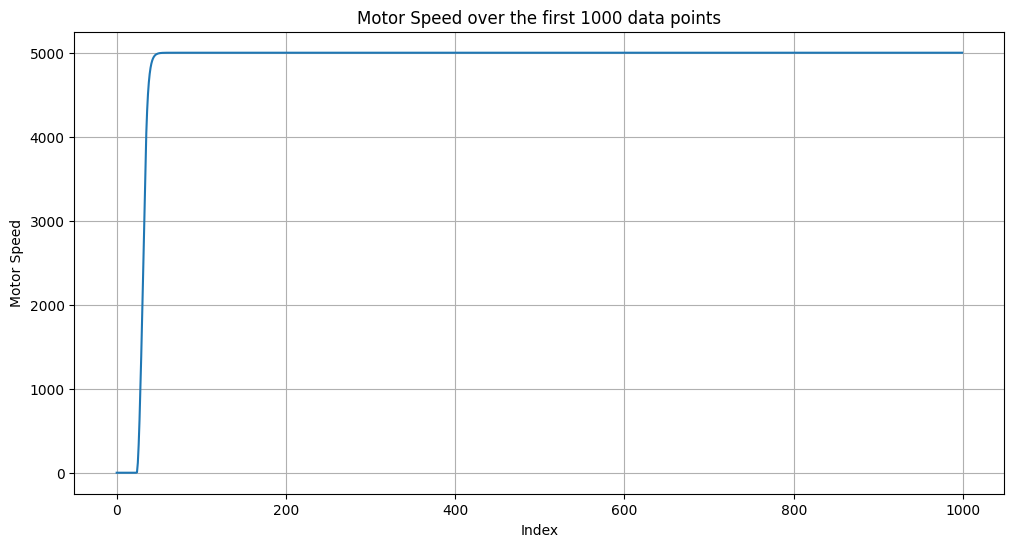

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=motor_speed_subset)
plt.xlabel('Index')
plt.ylabel('Motor Speed')
plt.title("Motor Speed over the first 1000 data points")
plt.grid(True)
plt.show()

### Preparing Data for Temperature Prediction

To predict the `ambient` temperature, we'll follow these steps:
1.  **Define Features (X) and Target (y)**: Separate the dataset into features (input variables) and the target variable (`ambient`).
2.  **Split Data**: Divide the data into training and testing sets to evaluate the model's performance on unseen data.
3.  **Scale Features**: Apply `StandardScaler` to normalize the numerical features, which can improve the performance of many machine learning algorithms.

In [ ]:
# Define features (X) and target (y)
# We'll use all columns except 'ambient' and 'profile_id' as features to predict 'ambient' temperature.
X = df.drop(columns=['ambient', 'profile_id'])
y = df['ambient']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (1330816, 11)
Target shape: (1330816,)


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (1064652, 11)
X_test shape: (266164, 11)
y_train shape: (1064652,)
y_test shape: (266164,)


In [ ]:
# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")


Features scaled successfully!


### Model Training: Linear Regression

Now that the data is prepared, we can train a Linear Regression model to predict the `ambient` temperature.

In [ ]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")


Linear Regression model trained successfully!


### Model Evaluation

After training, we evaluate the model's performance on the test set using various metrics:
-   **R-squared ($R^2$)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher $R^2$ indicates a better fit.
-   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual observations. It measures the average magnitude of the errors in a set of predictions, without considering their direction.
-   **Mean Squared Error (MSE)**: The average of the squares of the errors. It gives higher weight to larger errors, making it useful when large errors are particularly undesirable.
-   **Root Mean Squared Error (RMSE)**: The square root of the MSE. It provides an error metric in the same units as the target variable, making it more interpretable than MSE.

In [ ]:
# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


R-squared: 0.4599
Mean Absolute Error (MAE): 1.1087
Mean Squared Error (MSE): 2.0051
Root Mean Squared Error (RMSE): 1.4160


In [ ]:
# Define features (X) and target (y) for predicting 'stator_yoke'
X = df.drop(columns=['stator_yoke', 'profile_id'])
y = df['stator_yoke']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1330816, 11)
Target shape: (1330816,)


In [ ]:
#Split the training and Testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(f"X_train Shape:{X_train.shape}")
print(f'X_test shape:{X_test.shape}')
print(f"y_train shape:{y_train.shape}")
print(f"y_test shape:{y_test.shape}")

X_train Shape:(1064652, 11)
X_test shape:(266164, 11)
y_train shape:(1064652,)
y_test shape:(266164,)


In [ ]:
#Standard Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
#Train the model
model=LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [ ]:
#Model_Evaluation
y_pred = model.predict(X_test_scaled)

In [ ]:
r2_1= r2_score(y_test,y_pred)
mae_1=mean_absolute_error(y_test,y_pred)
mse_1=mean_squared_error(y_test,y_pred)
rmse_1=np.sqrt(mse_1)

In [ ]:
print(f"R2 Squared : {r2_1:.4f}")
print(f"Mean Absolute Error (MAE): {mae_1:.4f}")
print(f"Mean Squared Error (MSE): {mse_1:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_1:.4f}")

R2 Squared : 0.9980
Mean Absolute Error (MAE): 0.6154
Mean Squared Error (MSE): 0.8149
Root Mean Squared Error (RMSE): 0.9027


In [ ]:
# Calculate residuals
residuals = y_test - y_pred

print("First 5 residuals:")
display(residuals.head())

print("Residuals statistics:")
display(residuals.describe())

First 5 residuals:


,stator_yoke
294684,-0.008512
668769,-0.277183
1326035,1.732568
879218,-1.020013
75406,1.021853


Residuals statistics:


,stator_yoke
count,266164.000000
mean,-0.000083
std,0.902717
min,-4.634639
25%,-0.450658
50%,-0.021939
75%,0.378657
max,13.071823


In [ ]:
#Visulation of the result


### Visualization: Actual vs. Predicted `stator_yoke`

Let's visualize the relationship between the actual `stator_yoke` values (`y_test`) and the predicted values (`y_pred`). A good model would show points clustering closely around the diagonal line, indicating that predictions are close to actuals.

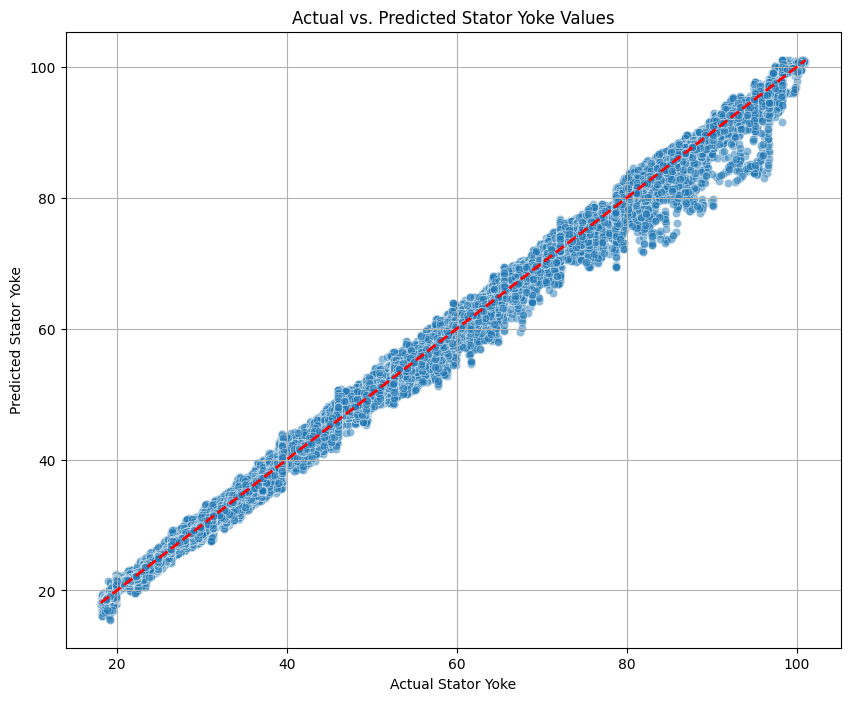

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Stator Yoke')
plt.ylabel('Predicted Stator Yoke')
plt.title('Actual vs. Predicted Stator Yoke Values')
plt.grid(True)
plt.show()

### Predicting New Values with the Trained Model

To predict new values, we need to provide input features in the same format and scale as the training data. Below is an example of how to create a dummy new data point, scale it, and then use the `model.predict()` method.

In [ ]:
# Create a dummy new data point for prediction.
# It's crucial that the new data point has the same columns (features) as X_train, and in the same order.
# The 'profile_id' column was dropped from X, so we ensure it's not in the new_data as well.

# Get the feature column names from X_train (which was derived from df.drop(['stator_yoke', 'profile_id']))
feature_columns = X_train.columns

# Create a dictionary with dummy values for each feature
# For demonstration, we'll use the mean of each feature from the original DataFrame as a representative point.
new_data_values = df[feature_columns].mean().to_dict()

# Convert the dictionary to a pandas DataFrame, ensuring the correct order of columns
new_data = pd.DataFrame([new_data_values], columns=feature_columns)

print("New data point to predict:")
display(new_data)

# Scale the new data point using the previously fitted scaler
new_data_scaled = scaler.transform(new_data)

print("Scaled new data point:")
display(new_data_scaled)

# Make a prediction using the trained model
predicted_stator_yoke = model.predict(new_data_scaled)

print(f"Predicted 'stator_yoke' for the new data point: {predicted_stator_yoke[0]:.4f}")

New data point to predict:


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,ambient,torque
0,54.279005,36.229995,66.342745,-25.133809,56.878582,2202.080728,-68.71681,37.412782,58.506776,24.565256,31.106032


Scaled new data point:


array([[-2.03964756e-04,  6.79940428e-05,  6.84376433e-04,
        -2.97623208e-05,  6.15841272e-04, -7.28729457e-05,
        -1.55409278e-04, -1.08811594e-04,  7.70592141e-04,
         3.62855420e-04, -1.08659925e-04]])

Predicted 'stator_yoke' for the new data point: 48.1880


### Function for Custom Predictions

Below, I've defined a function `predict_stator_yoke_custom` that allows you to input custom values for the 11 features (excluding `stator_yoke` and `profile_id`) and get a prediction for the `stator_yoke`.

In [ ]:
def predict_stator_yoke_custom(u_q, coolant, stator_winding, u_d, stator_tooth, motor_speed, i_d, i_q, pm, ambient, torque):
    """
    Predicts 'stator_yoke' for custom user-provided input features.

    Args:
        u_q (float): Direct axis voltage.
        coolant (float): Coolant temperature.
        stator_winding (float): Stator winding temperature.
        u_d (float): Quadrature axis voltage.
        stator_tooth (float): Stator tooth temperature.
        motor_speed (float): Motor speed.
        i_d (float): Direct axis current.
        i_q (float): Quadrature axis current.
        pm (float): Permanent magnet temperature.
        ambient (float): Ambient temperature.
        torque (float): Torque.

    Returns:
        float: Predicted 'stator_yoke' value.
    """

    # Create a DataFrame from the input values, ensuring correct column order
    input_data = pd.DataFrame([[u_q, coolant, stator_winding, u_d, stator_tooth,
                                  motor_speed, i_d, i_q, pm, ambient, torque]],
                                columns=X_train.columns)

    # Scale the input data using the pre-fitted scaler
    input_data_scaled = scaler.transform(input_data)

    # Make a prediction using the trained model
    prediction = model.predict(input_data_scaled)

    return prediction[0]

print("Function 'predict_stator_yoke_custom' created successfully.")

Function 'predict_stator_yoke_custom' created successfully.


#### Example Usage of the Custom Prediction Function

Here's how you can use the `predict_stator_yoke_custom` function with some example values. For demonstration purposes, I'll use the mean values from the original dataset for each feature as a sample input.

In [ ]:
# Get mean values for each feature from the original DataFrame for a sample input
# Make sure to exclude 'stator_yoke' and 'profile_id' as they are not input features
sample_input_values = df[X_train.columns].mean().values

# Unpack the mean values into the function arguments
predicted_value = predict_stator_yoke_custom(*sample_input_values)

print(f"Predicted 'stator_yoke' for sample input: {predicted_value:.4f}")

# You can also try with custom values:
# custom_predicted_value = predict_stator_yoke_custom(50, 30, 60, -20, 55, 2000, -70, 35, 50, 25, 30)
# print(f"Predicted 'stator_yoke' for custom input: {custom_predicted_value:.4f}")

Predicted 'stator_yoke' for sample input: 48.1880
